In [1]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

from src.dataset import BeeSegmentationDataset
from src.models.base import UNet3

In [2]:
dataset = BeeSegmentationDataset("data/images", "data/masks")

# Split: train/test -> train + test
train_len = int(0.0001 * len(dataset))
test_len = len(dataset) - train_len
train_val_dataset, test_dataset = random_split(dataset, [train_len, test_len], generator=torch.Generator().manual_seed(42))

# Now split train_val into train/val (80/20)
val_len = int(0.2 * len(train_val_dataset))
train_len = len(train_val_dataset) - val_len
train_dataset, val_dataset = random_split(train_val_dataset, [train_len, val_len], generator=torch.Generator().manual_seed(42))

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 11, Val: 2, Test: 130253


In [3]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

In [4]:
device = torch.device("cpu")# "cuda" if torch.cuda.is_available() else "cpu")

model = UNet3().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
weights = torch.tensor([0.3, 1.0, 1.0]).to(device)  # Tune as needed
criterion = nn.CrossEntropyLoss(weight=weights)

In [5]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    epoch_loss = 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)

        outputs = model(images)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
    return epoch_loss / len(loader)

In [6]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    val_loss = 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        loss = criterion(outputs, masks)
        val_loss += loss.item()
    return val_loss / len(loader)


In [12]:
num_epochs = 100
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    # val_loss = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    # val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs}  Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}")

Epoch 1/100  Train Loss: 0.7357  Val Loss: 0.7900
Epoch 2/100  Train Loss: 0.7337  Val Loss: 0.7900
Epoch 3/100  Train Loss: 0.7306  Val Loss: 0.7900
Epoch 4/100  Train Loss: 0.7243  Val Loss: 0.7900
Epoch 5/100  Train Loss: 0.7176  Val Loss: 0.7900
Epoch 6/100  Train Loss: 0.7122  Val Loss: 0.7900
Epoch 7/100  Train Loss: 0.7021  Val Loss: 0.7900
Epoch 8/100  Train Loss: 0.6924  Val Loss: 0.7900
Epoch 9/100  Train Loss: 0.6828  Val Loss: 0.7900
Epoch 10/100  Train Loss: 0.6750  Val Loss: 0.7900
Epoch 11/100  Train Loss: 0.6766  Val Loss: 0.7900
Epoch 12/100  Train Loss: 0.7295  Val Loss: 0.7900
Epoch 13/100  Train Loss: 0.6881  Val Loss: 0.7900
Epoch 14/100  Train Loss: 0.8367  Val Loss: 0.7900
Epoch 15/100  Train Loss: 0.6986  Val Loss: 0.7900
Epoch 16/100  Train Loss: 0.7351  Val Loss: 0.7900
Epoch 17/100  Train Loss: 0.7121  Val Loss: 0.7900
Epoch 18/100  Train Loss: 0.6804  Val Loss: 0.7900
Epoch 19/100  Train Loss: 0.7214  Val Loss: 0.7900
Epoch 20/100  Train Loss: 0.7040  Val Lo

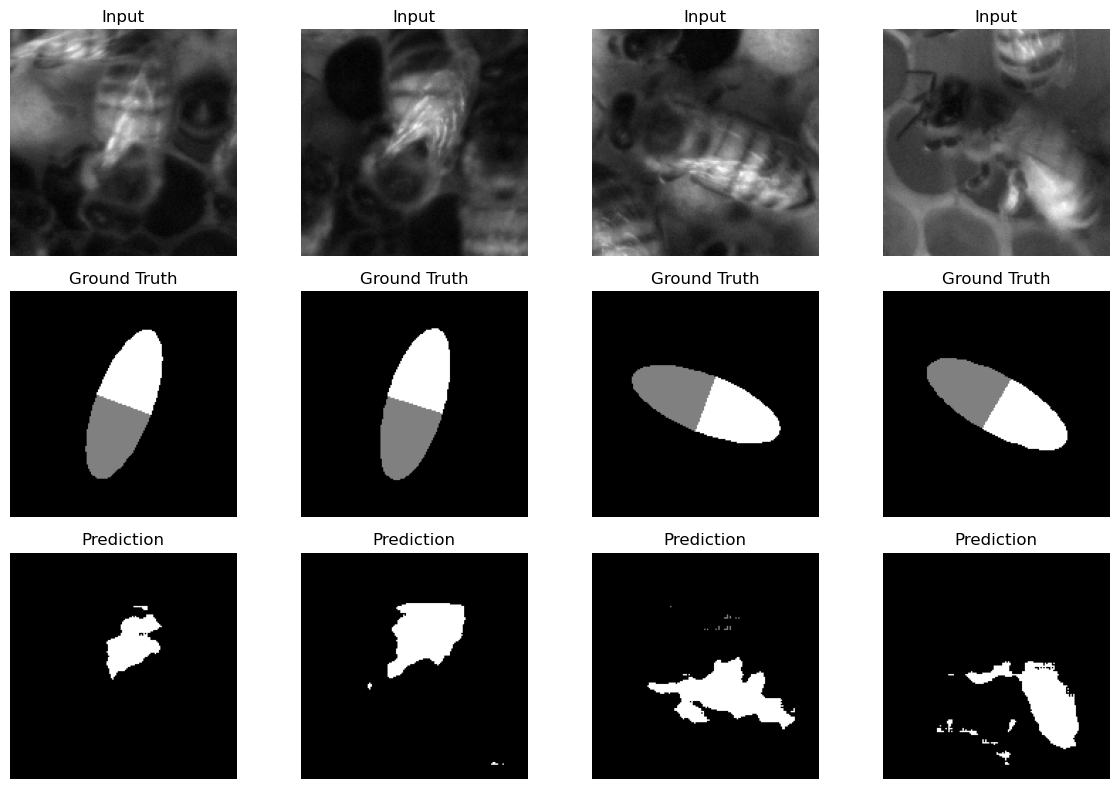

In [13]:
model.eval()
images, masks = next(iter(test_loader))
images = images.to(device)
outputs = model(images).argmax(dim=1).cpu()

fig, axs = plt.subplots(3, 4, figsize=(12, 8))
for i in range(4):
    axs[0, i].imshow(images[i][0].cpu(), cmap="gray")
    axs[0, i].set_title("Input")

    axs[1, i].imshow(masks[i].cpu(), cmap="gray")
    axs[1, i].set_title("Ground Truth")

    axs[2, i].imshow(outputs[i], cmap="gray")
    axs[2, i].set_title("Prediction")

for ax in axs.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()


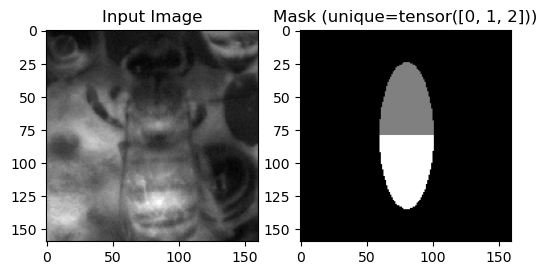

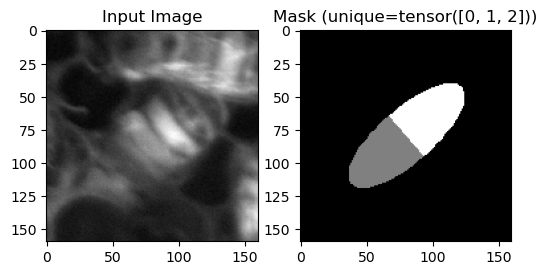

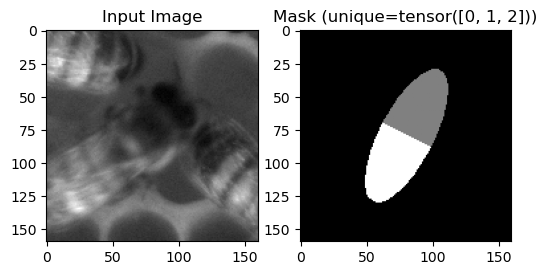

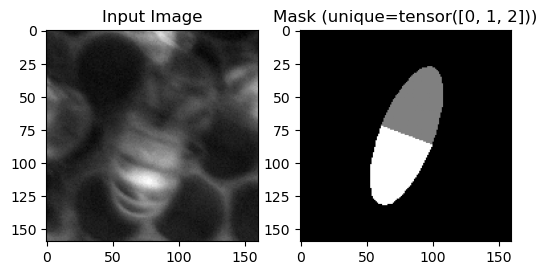

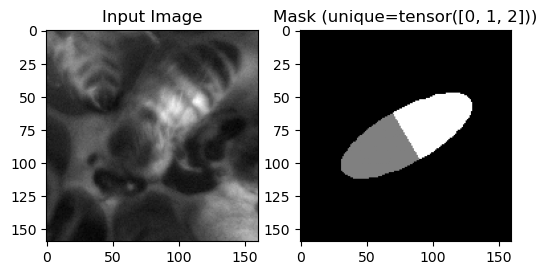

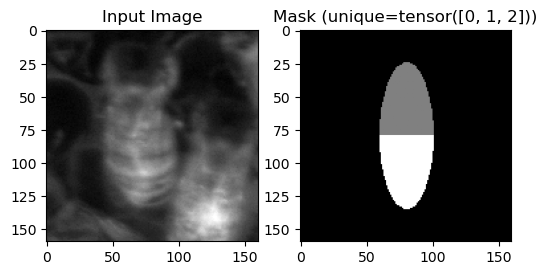

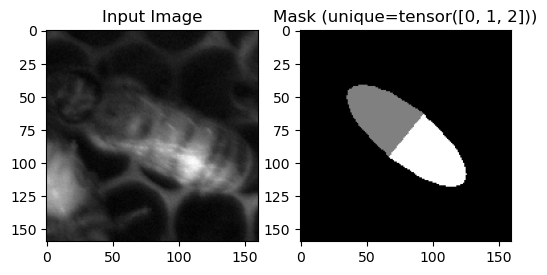

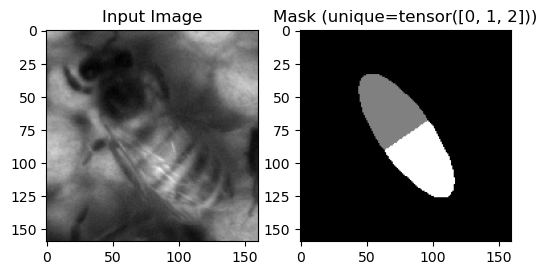

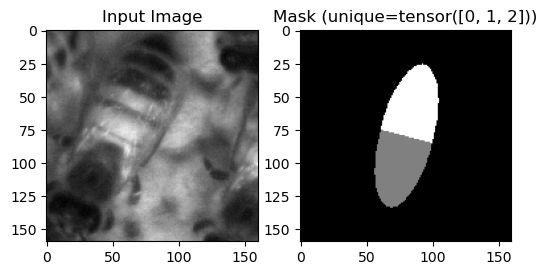

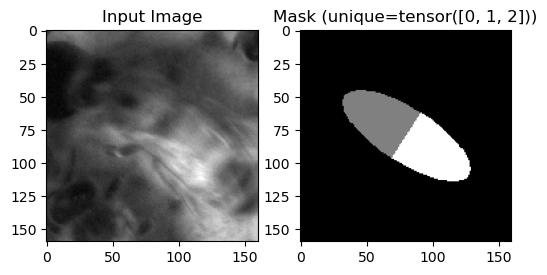

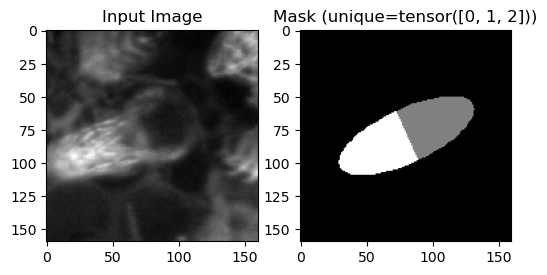

In [9]:
for i in range(11):
    image, mask = train_dataset[i]
    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    plt.imshow(image[0], cmap='gray')
    plt.title("Input Image")
    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='gray')
    plt.title(f"Mask (unique={torch.unique(mask)})")
    plt.show()
